## 1. Import Library

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report, precision_score, recall_score, confusion_matrix, accuracy_score

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression


import warnings
warnings.filterwarnings('ignore')
sns.set_style('darkgrid')
%matplotlib inline

## 2. Import Dataset

In [ ]:
resume_data = pd.read_csv('resumes.csv')
resume_data.head()

,Data,Role,Work
0,Anubhav Kumar Singh\t\t\n\n To work in a gl...,Peoplesoft Admin,Peoplesoft
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\n7+ years...,Peoplesoft Admin,Peoplesoft
2,PeopleSoft Database Administrator\n ...,Peoplesoft Admin,Peoplesoft
3,Murali\n\nExperience Summary \n\nI have 6 year...,Peoplesoft Admin,Peoplesoft
4,"Priyanka Ramadoss\n61/46, MountPleasant, \nCoo...",Peoplesoft Admin,Peoplesoft


## 3. Data Preprocessing
### 3.1 LabelEncoder

In [ ]:
from sklearn.preprocessing import LabelEncoder
Encoder=LabelEncoder()
resume_data["LebelEncoding"]=Encoder.fit_transform(resume_data ["Work"])

resume_data

,Data,Role,Work,LebelEncoding
0,Anubhav Kumar Singh\t\t\n\n To work in a gl...,Peoplesoft Admin,Peoplesoft,0
1,Profile Summary:\t\t\t\t\t\t\t\t\t\t\n7+ years...,Peoplesoft Admin,Peoplesoft,0
2,PeopleSoft Database Administrator\n ...,Peoplesoft Admin,Peoplesoft,0
3,Murali\n\nExperience Summary \n\nI have 6 year...,Peoplesoft Admin,Peoplesoft,0
4,"Priyanka Ramadoss\n61/46, MountPleasant, \nCoo...",Peoplesoft Admin,Peoplesoft,0
...,...,...,...,...
74,Workday Integration Consultant\n\nName ...,Workday Hexaware,Workday,3
75,Seeking suitable positions in Workday HCM as ...,Workday Hexaware,Workday,3
76,\nWORKDAY | HCM | FCM\nName \t\t: Kumar S.S\nR...,Workday Hexaware,Workday,3
77,Venkateswarlu.B\t\t\t\t\t\t\t\tWorkday Consult...,Workday Hexaware,Workday,3


In [ ]:
resume_data.describe()

,LebelEncoding
count,79.000000
mean,1.455696
std,1.141271
min,0.000000
25%,0.500000
50%,1.000000
75%,3.000000
max,3.000000


In [ ]:
resume_data.isnull().sum()

,0
Data,0
Role,0
Work,0
LebelEncoding,0


## 4. Model Building

### 4.1 Train - Test Split

In [ ]:
x = resume_data['Data'].values
y = resume_data['Work'].values


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=45, test_size=0.25,stratify=y)
x_train.shape, x_test.shape

((59,), (20,))

### 4.2 TF-IDF Vectorization

In [ ]:
tfidf_vector = TfidfVectorizer(sublinear_tf=True,stop_words='english')

In [ ]:
x_train = tfidf_vector.fit_transform(x_train)
x_test = tfidf_vector.transform(x_test)

In [ ]:
x_train.shape, x_test.shape

((59, 3903), (20, 3903))

In [ ]:
print(y_train),print(y_test)

['Peoplesoft' 'React Dev' 'Peoplesoft' 'Workday' 'SQL Dev' 'SQL Dev'
 'React Dev' 'Peoplesoft' 'React Dev' 'Peoplesoft' 'React Dev' 'SQL Dev'
 'React Dev' 'React Dev' 'Workday' 'React Dev' 'SQL Dev' 'React Dev'
 'Peoplesoft' 'React Dev' 'React Dev' 'Workday' 'Peoplesoft' 'Peoplesoft'
 'Peoplesoft' 'SQL Dev' 'Workday' 'Workday' 'Workday' 'React Dev'
 'Workday' 'React Dev' 'SQL Dev' 'Workday' 'React Dev' 'Workday' 'SQL Dev'
 'Workday' 'Peoplesoft' 'Peoplesoft' 'SQL Dev' 'Peoplesoft' 'Workday'
 'SQL Dev' 'Peoplesoft' 'Workday' 'Peoplesoft' 'SQL Dev' 'Workday'
 'Workday' 'Workday' 'Peoplesoft' 'React Dev' 'React Dev' 'React Dev'
 'Peoplesoft' 'React Dev' 'React Dev' 'Workday']
['Peoplesoft' 'Peoplesoft' 'React Dev' 'Workday' 'Workday' 'React Dev'
 'React Dev' 'React Dev' 'Peoplesoft' 'React Dev' 'SQL Dev' 'SQL Dev'
 'SQL Dev' 'SQL Dev' 'Workday' 'Workday' 'Peoplesoft' 'Workday'
 'Peoplesoft' 'React Dev']


(None, None)

# 5. Classification Models

## 5.1 KNN Classifier

In [ ]:
model_knn = KNeighborsClassifier(n_neighbors=41)
model_knn.fit(x_train, y_train)
y_pred = model_knn.predict(x_test)
accuracy_knn = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_knn.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_knn.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_knn,classification_report(y_test, y_pred)))
nb_score = model_knn.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_knn = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_knn = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_knn = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_knn = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 0.66
Accuracy of  test set    : 0.60
Classification report for classifier KNeighborsClassifier(n_neighbors=41):
              precision    recall  f1-score   support

  Peoplesoft       0.50      0.20      0.29         5
   React Dev       1.00      1.00      1.00         6
     SQL Dev       0.00      0.00      0.00         4
     Workday       0.42      1.00      0.59         5

    accuracy                           0.60        20
   macro avg       0.48      0.55      0.47        20
weighted avg       0.53      0.60      0.52        20




## 5.2 Decision Tree Classifier

In [ ]:
model_DT = DecisionTreeClassifier(criterion='gini')
model_DT.fit(x_train, y_train)
y_pred = model_DT.predict(x_test)
accuracy_DT = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_DT.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_DT.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_DT,classification_report(y_test, y_pred)))
nb_score = model_DT.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_DT = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_DT= round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_DT = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_DT = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier DecisionTreeClassifier():
              precision    recall  f1-score   support

  Peoplesoft       1.00      1.00      1.00         5
   React Dev       1.00      1.00      1.00         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20




## 5.3 Random Forest Classifier

In [ ]:
model_RF = RandomForestClassifier(n_estimators=200)
model_RF.fit(x_train, y_train)
y_pred = model_RF.predict(x_test)
accuracy_RF = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_RF.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_RF.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_RF,classification_report(y_test, y_pred)))
nb_score = model_RF.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)


precision_RF = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_RF = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_RF = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_RF = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 0.95
Classification report for classifier RandomForestClassifier(n_estimators=200):
              precision    recall  f1-score   support

  Peoplesoft       1.00      0.80      0.89         5
   React Dev       0.86      1.00      0.92         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20




## 5.4 Support Vectore Machine (SVM) Classifier

In [ ]:
model_svm = SVC()
model_svm.fit(x_train, y_train)
y_pred = model_svm.predict(x_test)
accuracy_svm = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_svm.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_svm.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_svm,classification_report(y_test, y_pred)))
nb_score = model_svm.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_svm = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_svm = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_svm = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_svm = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 0.95
Classification report for classifier SVC():
              precision    recall  f1-score   support

  Peoplesoft       1.00      0.80      0.89         5
   React Dev       0.86      1.00      0.92         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20




## 5.5 Logistic Regression

In [ ]:
model_lgr = LogisticRegression()
model_lgr.fit(x_train, y_train)
y_pred = model_lgr.predict(x_test)
accuracy_lgr = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_lgr.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_lgr.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_lgr,classification_report(y_test, y_pred)))
nb_score = model_lgr.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)


precision_lgr = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_lgr = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_lgr = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_lgr = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 0.95
Classification report for classifier LogisticRegression():
              precision    recall  f1-score   support

  Peoplesoft       1.00      0.80      0.89         5
   React Dev       0.86      1.00      0.92         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20




## 5.6 Bagging Classifier

In [ ]:
model_bagg = BaggingClassifier(KNeighborsClassifier(), max_samples=0.5, max_features=0.5)
model_bagg.fit(x_train, y_train)
y_pred = model_bagg.predict(x_test)
accuracy_bagg = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_bagg.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_bagg.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_bagg,classification_report(y_test, y_pred)))
nb_score = model_bagg.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_bagg = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_bagg = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_bagg = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_bagg = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 0.98
Accuracy of  test set    : 0.95
Classification report for classifier BaggingClassifier(estimator=KNeighborsClassifier(), max_features=0.5,
                  max_samples=0.5):
              precision    recall  f1-score   support

  Peoplesoft       1.00      0.80      0.89         5
   React Dev       1.00      1.00      1.00         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       0.83      1.00      0.91         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20




## 5.7 AdaBoost Classifier

In [ ]:
model_Adaboost = AdaBoostClassifier(n_estimators=100)
model_Adaboost.fit(x_train, y_train)
y_pred = model_Adaboost.predict(x_test)
accuracy_Adaboost = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_Adaboost.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_Adaboost.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_Adaboost,classification_report(y_test, y_pred)))
nb_score = model_Adaboost.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_Adaboost = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_Adaboost = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_Adaboost = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_Adaboost = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 0.42
Accuracy of  test set    : 0.45
Classification report for classifier AdaBoostClassifier(n_estimators=100):
              precision    recall  f1-score   support

  Peoplesoft       0.83      1.00      0.91         5
   React Dev       0.00      0.00      0.00         6
     SQL Dev       0.29      1.00      0.44         4
     Workday       0.00      0.00      0.00         5

    accuracy                           0.45        20
   macro avg       0.28      0.50      0.34        20
weighted avg       0.27      0.45      0.32        20




## 5.8 Gradient Boosting Classifier

In [ ]:
model_GradientBoost = GradientBoostingClassifier(n_estimators=100,learning_rate=1.0,max_depth=1, random_state=0)
model_GradientBoost.fit(x_train, y_train)
y_pred = model_GradientBoost.predict(x_test)
accuracy_GradientBoost = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_GradientBoost.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_GradientBoost.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_GradientBoost,classification_report(y_test, y_pred)))
nb_score = model_GradientBoost.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_Gradientboost = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_Gradientboost = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_Gradientboost = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_Gradientboost = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0):
              precision    recall  f1-score   support

  Peoplesoft       1.00      1.00      1.00         5
   React Dev       1.00      1.00      1.00         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20




## 5.9 Naive Bayes Classifier

In [ ]:
model_NB =MultinomialNB(alpha=1, fit_prior=False, class_prior=None)
model_NB.fit(x_train, y_train)
y_pred = model_NB.predict(x_test)
accuracy_NB = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_NB.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_NB.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_NB,classification_report(y_test, y_pred)))
nb_score = model_NB.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_NB = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_NB = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_NB = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_NB = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 0.95
Classification report for classifier MultinomialNB(alpha=1, fit_prior=False):
              precision    recall  f1-score   support

  Peoplesoft       1.00      0.80      0.89         5
   React Dev       1.00      1.00      1.00         6
     SQL Dev       1.00      1.00      1.00         4
     Workday       0.83      1.00      0.91         5

    accuracy                           0.95        20
   macro avg       0.96      0.95      0.95        20
weighted avg       0.96      0.95      0.95        20




# 5.10 Hyper Parameter Tuning

In [ ]:

X_text = resume_data['Data'].values
y_labels = resume_data['Work'].values


x_train_text, x_test_text, y_train, y_test = train_test_split(
    X_text, y_labels, random_state=45, test_size=0.25, stratify=y_labels
)



models_and_parameters = {
    'KNeighborsClassifier': {
        'model': KNeighborsClassifier(),
        'params': {
            'clf__n_neighbors': [5, 11, 21, 41],
            'clf__weights': ['uniform', 'distance'],
            'tfidf__sublinear_tf': [True, False]
        }
    },
    'DecisionTreeClassifier': {
        'model': DecisionTreeClassifier(random_state=42),
        'params': {
            'clf__criterion': ['gini', 'entropy'],
            'clf__max_depth': [None, 10, 20],
            'clf__min_samples_split': [2, 5],
            'tfidf__ngram_range': [(1, 1), (1, 2)]
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [None, 10, 20],
            'clf__min_samples_split': [2, 5],
            'tfidf__max_df': [0.75, 1.0]
        }
    },
    'SVC': {
        'model': SVC(),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale', 'auto'],
            'tfidf__use_idf': [True, False]
        }
    },
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=1000),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__solver': ['liblinear', 'saga'],
            'tfidf__ngram_range': [(1,1), (1,2)]
        }
    },
    'BaggingClassifier_KNN': {
        'model': BaggingClassifier(estimator=KNeighborsClassifier(), random_state=42),
        'params': {
            'clf__n_estimators': [10, 50],
            'clf__max_samples': [0.5, 1.0],
            'clf__max_features': [0.5, 1.0],
            'tfidf__sublinear_tf': [True, False]
        }
    },
    'AdaBoostClassifier': {
        'model': AdaBoostClassifier(random_state=42),
        'params': {
            'clf__n_estimators': [50, 100],
            'clf__learning_rate': [0.1, 0.5, 1.0],
            'tfidf__ngram_range': [(1,1), (1,2)]
        }
    },
    'GradientBoostingClassifier': {
        'model': GradientBoostingClassifier(random_state=0),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__learning_rate': [0.05, 0.1, 1.0],
            'clf__max_depth': [1, 3, 5],
            'tfidf__max_df': [0.75, 1.0]
        }
    },
    'MultinomialNB': {
        'model': MultinomialNB(),
        'params': {
            'clf__alpha': [0.1, 0.5, 1.0],
            'clf__fit_prior': [True, False],
            'tfidf__use_idf': [True, False]
        }
    }
}




In [ ]:

best_estimators = {}
results_summary = []

for model_name, config in models_and_parameters.items():
    print(f"\n--- Tuning {model_name} ---")
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english')),
        ('clf', config['model'])
    ])


    param_grid = {}
    for key, value in config['params'].items():
        param_grid[key] = value
        if 'tfidf__' not in key and 'clf__' not in key :
             param_grid[f'clf__{key}'] = value

    grid_search = GridSearchCV(pipeline, param_grid, cv=2, n_jobs=-1, verbose=1, scoring='accuracy')

    print(f"Fitting {model_name} with parameters: {param_grid}")
    grid_search.fit(x_train_text, y_train)

    best_estimators[model_name] = grid_search.best_estimator_

    print(f"\nBest score for {model_name}: {grid_search.best_score_:.3f}")
    print(f"Best parameters for {model_name}:")
    best_params_found = grid_search.best_params_
    for param, val in best_params_found.items():
        print(f"\t{param}: {val!r}")


    y_pred_tuned = grid_search.predict(x_test_text)
    test_accuracy = accuracy_score(y_test, y_pred_tuned)
    print(f"Test set accuracy for tuned {model_name}: {test_accuracy:.3f}")

    results_summary.append({
        'Model': model_name,
        'Best CV Score': grid_search.best_score_,
        'Test Accuracy': test_accuracy,
        'Best Params': best_params_found
    })

print("\n\n--- Hyperparameter Tuning Summary ---")
results_df = pd.DataFrame(results_summary)
print(results_df)

## 6. Model Evaluation

In [ ]:
Evaluation = {"Models":["KNN Classifier","DecisionTree Classifier","RandomForest Classifier","SVM Classifier",
                        "Logistic Regression","Bagging Classifier","AdaBoost Classifier","Gradient Boosting Classifier","Naive Bayes Classifier"],\
            "Train_Accuracy(%)":[model_knn.score(x_train, y_train),model_DT.score(x_train, y_train),model_RF.score(x_train, y_train),model_svm.score(x_train, y_train),model_lgr.score(x_train, y_train),
                                 model_bagg.score(x_train, y_train),model_Adaboost.score(x_train, y_train),model_GradientBoost.score(x_train, y_train), model_NB.score(x_train, y_train)],
            "Test_Accuracy(%)":[accuracy_knn,accuracy_DT,accuracy_RF,accuracy_svm,accuracy_lgr,accuracy_bagg,accuracy_Adaboost,accuracy_GradientBoost,accuracy_NB],\
            "Precision(%)":[precision_knn,precision_DT,precision_RF,precision_svm,precision_lgr,precision_bagg,precision_Adaboost,precision_Gradientboost,precision_NB],\
            "Recall(%)":[recall_knn,recall_DT,recall_RF,recall_svm,recall_lgr,recall_bagg,recall_Adaboost,recall_Gradientboost,recall_NB],\
            "F1-Score(%)":[f1_knn,f1_DT,f1_RF,f1_svm,f1_lgr,f1_bagg,f1_Adaboost,f1_Gradientboost,f1_NB]}
table = pd.DataFrame(Evaluation)
table

,Models,Train_Accuracy(%),Test_Accuracy(%),Precision(%),Recall(%),F1-Score(%)
0,KNN Classifier,0.661017,0.60,0.48,0.55,0.47
1,DecisionTree Classifier,1.000000,1.00,1.00,1.00,1.00
2,RandomForest Classifier,1.000000,0.95,0.96,0.95,0.95
3,SVM Classifier,1.000000,0.95,0.96,0.95,0.95
4,Logistic Regression,1.000000,0.95,0.96,0.95,0.95
5,Bagging Classifier,0.983051,0.95,0.96,0.95,0.95
6,AdaBoost Classifier,0.423729,0.45,0.28,0.50,0.34
7,Gradient Boosting Classifier,1.000000,1.00,1.00,1.00,1.00
8,Naive Bayes Classifier,1.000000,0.95,0.96,0.95,0.95


In [ ]:
model_names = ["KNN","DecisionTree","RandomForest ","SVM ", "Logistic Regression",
               "Bagging","AdaBoost","Gradient Boosting ","Naive Bayes"]
Test_accuracies = [accuracy_knn*100,accuracy_DT*100,accuracy_RF*100,
              accuracy_svm*100,accuracy_lgr*100,accuracy_bagg*100,
              accuracy_Adaboost*100,accuracy_GradientBoost*100,accuracy_NB*100]
Train_accuracies=[model_knn.score(x_train, y_train)*100,model_DT.score(x_train, y_train)*100,
                  model_RF.score(x_train, y_train)*100,model_svm.score(x_train, y_train)*100,
                  model_lgr.score(x_train, y_train)*100,model_bagg.score(x_train, y_train)*100,
                  model_Adaboost.score(x_train, y_train)*100,model_GradientBoost.score(x_train, y_train)*100,
                  model_NB.score(x_train, y_train)*100]

### 6.1 Train and Test Accuracy Plot

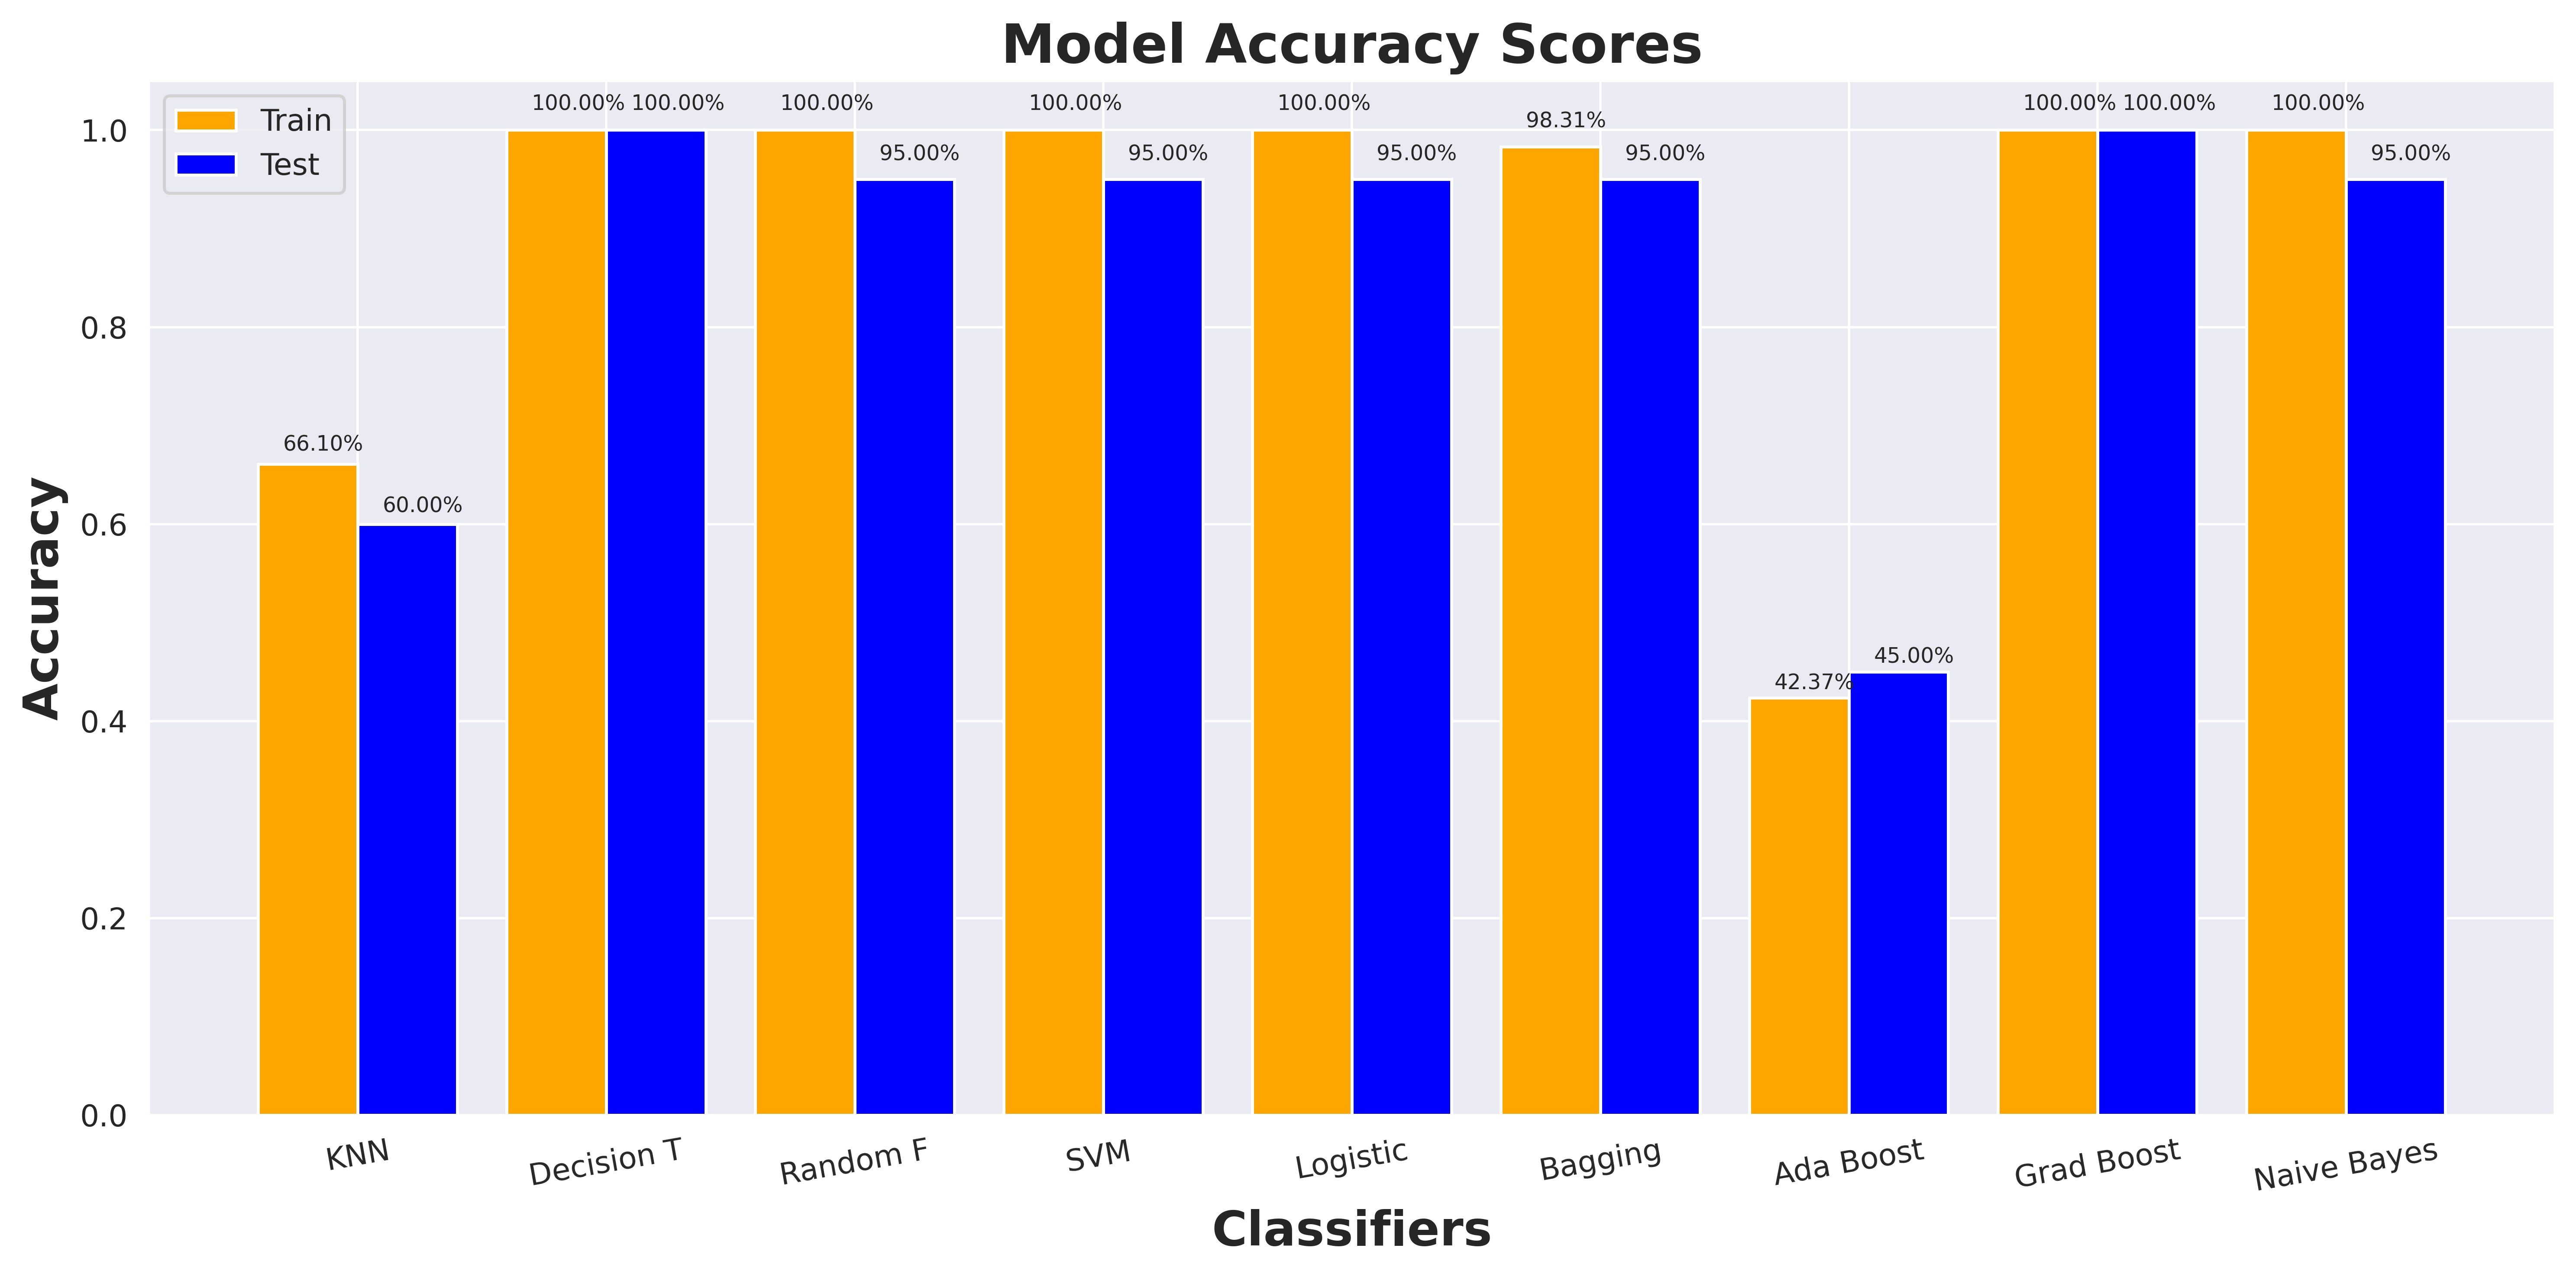

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

rcParams = {'xtick.labelsize':'12','ytick.labelsize':'14','axes.labelsize':'16'}
fig, axe = plt.subplots(1,1, figsize=(12,6), dpi=500)
x_pos = np.arange(len(table))
model_names = ["KNN", "Decision T", "Random F", "SVM ", "Logistic", "Bagging", "Ada Boost", "Grad Boost","Naive Bayes"]

bar1 = plt.bar(x_pos - 0.2, table['Train_Accuracy(%)'], width=0.4, label='Train', color= "Orange")
bar2 = plt.bar(x_pos + 0.2, table['Test_Accuracy(%)'], width=0.4, label='Test', color= "b")
plt.xticks(x_pos, model_names)

plt.xlabel("Classifiers", fontsize = 16, fontweight = 'bold')
plt.ylabel("Accuracy", fontsize = 16, fontweight = 'bold')
plt.title("Model Accuracy Scores", fontsize = 18, fontweight = 'bold')
plt.xticks(rotation = 10)
plt.legend()

for i, bar in enumerate(bar1):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Train_accuracies[i]), fontsize = 7)

for i, bar in enumerate(bar2):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Test_accuracies[i]), fontsize = 7)

pylab.rcParams.update(rcParams)
fig.tight_layout()
plt.show()
fig.savefig('IMG\Mod_Acc_Bar', dpi = 500)

## 7. Model Deployment

### 7.1 Pickle File

In [ ]:
import pickle
filename = 'modelDT.pkl'
pickle.dump(model_DT,open(filename,'wb'))

In [ ]:
import pickle
filename = 'vector.pkl'
pickle.dump(tfidf_vector,open(filename,'wb'))

# THE END !!